In [1]:
# Biblioteka numpy ułatwia pracę z macierzami i wielowymiarowymi tabelami.
import numpy as np

# Biblioteka Tensorflow posłuży nam do zbudowania modelu
import tensorflow as tf

# Biblioteka opencv-python
import cv2

# Wizualizacja danych. biblioteka typu open source do przetwarzania obrazu i uczenia maszynowego.
import matplotlib.pyplot as plt

# TensorFlow zawiera dostawcę danych dla MNIST, z którego będziemy korzystać.
import tensorflow_datasets as tfds

In [2]:
# tfds.load w rzeczywistości ładuje zestaw danych (lub pobiera, a następnie ładuje, jeśli używasz go po raz pierwszy)
# w naszym przypadku interesuje nas MNIST; nazwa zbioru danych jest jedynym obowiązkowym argumentem
# Istnieją inne argumenty, które możemy określić które mogą nam się przydać
# with_info=True dostarczy nam również krotkę zawierającą informacje o wersji, funkcjach, Liczbie próbek
# wykorzystamy te informacje nieco poniżej i zapiszemy je w mnist_info
# as_supervised=True załaduje zestaw danych w strukturze 2-krotkowej (wejście, cel)
# alternatywnie, as_supervised=False, zwróci słownik
# oczywiście wolimy, aby nasze dane wejściowe i cele były oddzielone
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)

# Po załadowaniu zestawu danych możemy łatwo wyodrębnić zestaw danych szkoleniowych
# i testowych z utworzonymi referencjami
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

# Domyślnie TF ma zestawy danych treningowych i testowych, ale nie ma zestawów walidacyjnych
# dlatego musimy go samodzielnie podzielić
# zaczynamy od zdefiniowania liczby próbek walidacyjnych jako % próbek trenujących
# tutaj również używamy mnist_info (nie musimy liczyć obserwacji)
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples

# sparsujmy to na liczbę całkowitą, ponieważ liczba zmiennoprzecinkowa może po drodze spowodować błąd
num_validation_samples = tf.cast(num_validation_samples, tf.int64)

# zapiszmy też liczbę próbek testowych w dedykowanej zmiennej (zamiast używać mnist_info)
num_test_samples = mnist_info.splits['test'].num_examples

# jeszcze raz parsujemy na liczbę całkowitą (zamiast domyślnej liczby zmiennoprzecinkowej).
num_test_samples = tf.cast(num_test_samples, tf.int64)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.6Q334T_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.6Q334T_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [3]:
# należy znormalizować nasze dane, aby wynik był bardziej stabilny numerycznie
# dane wejściowe muszą być w zakresie liczbowym od 0 do 1

# zdefiniujmy funkcję o nazwie: scale, która pobierze obraz MNIST i jego etykietę
def scale(image, label):
    # potrzebujemy wartości zmiennoprzecinkowej float
    image = tf.cast(image, tf.float32)
    # ponieważ możliwe wartości dla wejść to od 0 do 255 (256 różnych odcieni szarości)
    # jeśli podzielimy każdy element przez 255, otrzymamy pożądany wynik:
    # wszystkie elementy będą znajdować się w przedziale od 0 do 1
    image /= 255.
    return image, label

# metoda .map() pozwala nam zastosować niestandardową transformację do danego zbioru danych
# już zdecydowaliśmy, że otrzymamy dane walidacyjne z mnist_train, więc
scaled_train_and_validation_data = mnist_train.map(scale)

# na koniec normalizujemy i grupujemy dane testowe
# aby miały taką samą wielkość jak dane trenujące i walidacyjne
# nie ma potrzeby ich mieszania, ponieważ nie będziemy trenować na danych testowych
# będzie to pojedyncza partia równa wielkości danych testowych
test_data = mnist_test.map(scale)

In [4]:
# ten parametr BUFFER_SIZE jest tutaj w przypadkach, gdy mamy do czynienia z ogromnymi zbiorami danych
# wtedy nie możemy przetasować całego zestawu danych za jednym razem,
# ponieważ nie możemy zmieścić go w pamięci
# więc zamiast tego TF przechowuje w pamięci tylko BUFFER_SIZE próbki na raz i tasuje je
# if BUFFER_SIZE=1 => żadne tasowanie nie nastąpi
# if BUFFER_SIZE > liczba próbek => tasowanie jest jednolite
# BUFFER_SIZE pomiędzy - optymalizacja obliczeniowa w celu przybliżenia jednolitego tasowania
BUFFER_SIZE = 10000

# jest łatwo dostępna metoda shuffle i musimy tylko określić rozmiar bufora
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

# po przeskalowaniu i przetasowaniu danych możemy przystąpić do faktycznego wyodrębniania
# danych trenujących i walidacyjnych
# nasze dane walidacyjne byłyby równe 10% zbioru uczącego, który już obliczyliśmy
# używamy metody take(), aby pobrać tyle próbek
# na koniec tworzymy partię o wielkości równej całkowitej liczbie próbek walidacyjnych
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)

# podobnie train_data to wszystko inne, więc pomijamy tyle próbek
# ile jest w zbiorze danych walidacyjnych
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [5]:
# zmienna określająca wielkość partii podawanej podczas trenowania
BATCH_SIZE = 100

# tworzymy partie danych treningowych
# jest to bardzo pomocne podczas treningu, ponieważ możemy iterować po różnych partiach
train_data = train_data.batch(BATCH_SIZE)

validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

# pobieramy i iterujemy partię walidacyjną (jest to jedyna partia)
# ponieważ as_supervized=True, mamy strukturę składającą się z dwóch krotek
validation_inputs, validation_targets = next(iter(validation_data))

print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [6]:
input_size = 784
output_size = 10
hidden_layer_size = 128

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(output_size, activation='softmax')
])

custom_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=custom_optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# ustawiamy ilość epok
NUM_EPOCHS = 30

# ustaw mechanizm wczesnego zatrzymywania, który ochroni nasz model przed przetrenowaniem
# ustawmy patience=2, aby być nieco tolerancyjnym na losowe wzrosty strat walidacji
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

# dopasowujemy model, określając dane treningowe, łączną liczbę epok
# oraz dane walidacyjne, które właśnie stworzyliśmy, w formacie: (INPUTS, TARGETS),
model.fit(train_data, # dane wejściowe trenujące
          epochs=NUM_EPOCHS, # maksymalna ilość epok gdyby wczesne zatrzymanie nie zadziałało
          callbacks=[early_stopping], # mechanizm "early stopping" zapobieganie przetrenowaniu
          validation_data=(validation_inputs, validation_targets), # dane walidacyjne
          verbose=1 # sposób pokazania treningu modelu
          )

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 54s 94ms/step - accuracy: 0.9271 - loss: 0.2402 - val_accuracy: 0.9747 - val_loss: 0.0884
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 50s 92ms/step - accuracy: 0.9789 - loss: 0.0676 - val_accuracy: 0.9828 - val_loss: 0.0562
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 57s 103ms/step - accuracy: 0.9859 - loss: 0.0452 - val_accuracy: 0.9865 - val_loss: 0.0455
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 48s 88ms/step - accuracy: 0.9887 - loss: 0.0363 - val_accuracy: 0.9883 - val_loss: 0.0404
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 50s 92ms/step - accuracy: 0.9906 - loss: 0.0295 - val_accuracy: 0.9923 - val_loss: 0.0271
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 80s 88ms/step - accuracy: 0.9926 - loss: 0.0242 - val_accuracy: 0.9935 - val_loss: 0.0285
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 51s 92ms/step - accuracy: 0.9931 - loss: 0.0212 - val_accuracy: 0.9915 - val_loss: 0.0311


In [11]:
test_loss, test_accuracy = model.evaluate(test_data)

# możemy zastosować estetyczne formatowanie
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy * 100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.9882 - loss: 0.0369
Test loss: 0.04. Test accuracy: 98.82%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prawdopodobieństwa dla klas od 0 do 9:
[[3.5292427e-08 1.1294851e-10 1.6441731e-03 7.5115372e-06 2.4488998e-16
  2.1083183e-13 5.3548163e-21 9.9834764e-01 2.9870606e-11 6.6571289e-07]]

--> ROZPOZNANA CYFRA TO: 7 <--



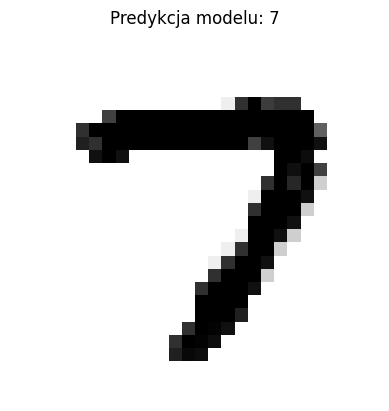

In [13]:
image_path = '/content/cyfra.png'

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is not None:
    img_resized = cv2.resize(img, (28, 28))

    img_inverted = cv2.bitwise_not(img_resized)

    img_normalized = img_inverted / 255.0

    img_ready = np.expand_dims(img_normalized, axis=0)
    img_ready = np.expand_dims(img_ready, axis=-1)

    predictions = model.predict(img_ready)

    predicted_digit = np.argmax(predictions)

    print(f"Prawdopodobieństwa dla klas od 0 do 9:\n{predictions}")
    print(f"\n--> ROZPOZNANA CYFRA TO: {predicted_digit} <--\n")

    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Predykcja modelu: {predicted_digit}")
    plt.axis('off')
    plt.show()
else:
    print(f"Nie znaleziono pliku '{image_path}'")